# Phase VI Part 2: biological function and pathway enrichment analysis 
+ In this notebook, DICE genes that were identified via betweennnes and eigenvector centrality measurement in which the distance was used as weight will be analyzed for enrichment analysis. 

In [1]:
import gseapy as gp
import pandas as pd
import json

In [2]:
dice_genes_v2 = pd.read_csv("../data/results/dice_genes_v2.tsv", sep="\t", usecols=[0])
dice_genes_v2 = list(dice_genes_v2["proteins"])
n = len(dice_genes_v2)

In [3]:
# Upload GO gmt file
go_set = "../data/enrichment/go.gmt"
kegg_set = "../data/enrichment/kegg.gmt"

In [4]:
# Upload the GO Terms and KEGG Term Mappings
kegg_map = open("../data/enrichment/kegg_mapping.json")
go_map = open(("../data/enrichment/go_mapping.json"))
kegg_terms_mapping = json.load(kegg_map)
go_term_mapping = json.load(go_map)

In [5]:
enr_go = gp.enrich(gene_list=dice_genes_v2, 
                 gene_sets=go_set, 
                 background=None,
                 outdir=None,
                 verbose=True)

2026-03-06 02:21:19,128 [INFO] User defined gene sets is given: ../data/enrichment/go.gmt
2026-03-06 02:21:19,236 [INFO] Run: go.gmt
2026-03-06 02:21:25,913 [INFO]   Background is not set! Use all 19591 genes in go.gmt.
2026-03-06 02:21:26,984 [INFO] Done.


In [6]:
enr_go.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,go.gmt,GO:0000014,1/12,0.596593,0.727585,1.659900,0.857373,DCLRE1C
1,go.gmt,GO:0000018,24/141,0.000080,0.000860,2.681222,25.291023,BCL6;PPP4C;PTPRC;IL7R;SMARCAD1;ACTL6A;WRAP53;C...
2,go.gmt,GO:0000019,1/7,0.411092,0.607984,2.937556,2.611307,MLH1
3,go.gmt,GO:0000022,1/12,0.596593,0.727585,1.659900,0.857373,RACGAP1
4,go.gmt,GO:0000027,8/29,0.000836,0.006153,5.053196,35.813641,MDN1;RPF2;BOP1;RPL24;MRM2;RPL5;RPL11;NOP2


In [7]:
# Save the results to a new df
results_go = enr_go.results
results_go.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,go.gmt,GO:0000014,1/12,0.596593,0.727585,1.659900,0.857373,DCLRE1C
1,go.gmt,GO:0000018,24/141,0.000080,0.000860,2.681222,25.291023,BCL6;PPP4C;PTPRC;IL7R;SMARCAD1;ACTL6A;WRAP53;C...
2,go.gmt,GO:0000019,1/7,0.411092,0.607984,2.937556,2.611307,MLH1
3,go.gmt,GO:0000022,1/12,0.596593,0.727585,1.659900,0.857373,RACGAP1
4,go.gmt,GO:0000027,8/29,0.000836,0.006153,5.053196,35.813641,MDN1;RPF2;BOP1;RPL24;MRM2;RPL5;RPL11;NOP2


In [8]:
# Filter out results with less than 0.05 adjusted p value
results_go_filt = results_go[results_go['Adjusted P-value'] < 0.05].copy()
print(f"Number of significant results: {len(results_go_filt)}")
results_go_filt.head()

Number of significant results: 1789


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1,go.gmt,GO:0000018,24/141,0.000080,0.000860,2.681222,25.291023,BCL6;PPP4C;PTPRC;IL7R;SMARCAD1;ACTL6A;WRAP53;C...
4,go.gmt,GO:0000027,8/29,0.000836,0.006153,5.053196,35.813641,MDN1;RPF2;BOP1;RPL24;MRM2;RPL5;RPL11;NOP2
5,go.gmt,GO:0000028,8/24,0.000199,0.001830,6.586282,56.141828,RPS27;RPS6;PRKDC;FAU;METTL17;RPSA;RPS14;RPS27L
9,go.gmt,GO:0000049,19/81,0.000004,0.000062,4.009925,49.670637,SSB;NSUN2;EIF1AX;TARBP1;SLFN13;TRMT11;RPUSD4;T...
11,go.gmt,GO:0000055,3/7,0.010802,0.049081,9.915643,44.898295,NUP88;RAN;SDAD1


In [9]:
# Map GO terms id to descriptions
results_go_filt["GO Term Name"] = results_go_filt["Term"].map(go_term_mapping)

In [10]:
# Add new overlap column and calculate the overlap ratio
results_go_filt["new_overlap"] = results_go_filt["Overlap"].str.split("/").str[0] + "/1453"
results_go_filt["new_overlap_rat"] = results_go_filt["Overlap"].apply(lambda x: int(x.split("/")[0]) / n)

# Reorder the df
results_go_filt = results_go_filt.iloc[:, [0, 1, 8, 9, 10,2,3,4,5,6,7]]

In [11]:
# Sort the results based on new overlap ratio
results_go_filt.sort_values("new_overlap_rat", ascending=False, inplace=True)

In [12]:
# Check the final df 
results_go_filt.head()

,Gene_set,Term,GO Term Name,new_overlap,new_overlap_rat,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
4373,go.gmt,GO:0043933,protein-containing complex organization,279/1453,0.192017,279/1964,1.113099e-29,3.114758e-27,2.379392,158.628910,KCNG1;SF3B6;SAR1B;CSNK2B;RDX;AP2S1;AGTR1;RPL13...
7094,go.gmt,GO:0140513,nuclear protein-containing complex,277/1453,0.190640,277/1445,2.221954e-54,2.253895e-51,3.508384,433.430022,CPSF4;SLBP;SF3B6;ERCC3;HEATR1;CSNK2B;BMS1;RPS2...
4435,go.gmt,GO:0044419,biological process involved in interspecies in...,274/1453,0.188575,274/1918,1.620720e-29,4.384048e-27,2.390639,158.480494,ADARB1;GRN;CSNK2B;AGTR1;PSMA2;RPL30;ITGAX;POMC...
927,go.gmt,GO:0005739,mitochondrion,272/1453,0.187199,272/1782,3.304807e-34,1.489917e-31,2.600204,200.456268,HEATR1;POLRMT;MCL1;NDUFB2;AK3;AFG3L2;PMAIP1;CM...
3461,go.gmt,GO:0033554,cellular response to stress,268/1453,0.184446,268/1984,5.640222e-25,9.535500e-23,2.218993,123.896845,UBE2D3;SMC3;SAR1B;GRN;ERCC3;PPP4C;PSMA2;MCL1;P...


In [13]:
# # Save GO encrichment analysis results
# results_go_filt.to_csv("../data/enrichment/dice_v2_go_results.tsv", sep="\t", index=False)

### Part 2: KEGG pathway enrichment analysis

In [14]:
enr_kegg = gp.enrich(gene_list=dice_genes_v2, 
                 gene_sets=kegg_set, 
                 background=None,
                 outdir=None,
                 verbose=True)

2026-03-06 02:21:27,150 [INFO] User defined gene sets is given: ../data/enrichment/kegg.gmt
2026-03-06 02:21:27,173 [INFO] Run: kegg.gmt
2026-03-06 02:21:27,193 [INFO]   Background is not set! Use all 8011 genes in kegg.gmt.
2026-03-06 02:21:27,232 [INFO] Done.


In [15]:
# Save the results to a new df
results_kegg = enr_kegg.results
results_kegg.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,kegg.gmt,hsa00010,9/68,0.371262,0.616773,1.241076,1.229718,PGAM1;ACSS2;ALDOA;AKR1A1;ENO2;LDHA;HK1;GAPDH;ENO3
1,kegg.gmt,hsa00020,1/30,0.973782,1.000000,0.393449,0.010453,FH
2,kegg.gmt,hsa00030,6/30,0.119380,0.256170,2.065650,4.390422,PRPS1;ALDOA;TALDO1;PGD;G6PD;TKT
3,kegg.gmt,hsa00040,1/34,0.983884,1.000000,0.346274,0.005626,AKR1A1
4,kegg.gmt,hsa00051,4/33,0.529217,0.760596,1.184235,0.753596,ENOSF1;HK1;ALDOA;TSTA3


In [16]:
# Filter out results with less than 0.05 adjusted p value
results_kegg_filt = results_kegg[results_kegg['Adjusted P-value'] < 0.05].copy()
print(f"Number of significant results: {len(results_kegg_filt)}")
results_kegg_filt.head()

Number of significant results: 95


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
14,kegg.gmt,hsa00190,29/133,3.954995e-04,0.002003,2.229522,17.469109,COX6A1;NDUFB5;NDUFB2;NDUFA2;COX7C;NDUFS5;UQCRQ...
71,kegg.gmt,hsa01521,20/79,4.174335e-04,0.002080,2.711045,21.095683,STAT3;PRKCB;GSK3B;MET;BRAF;GRB2;MTOR;BCL2L11;T...
72,kegg.gmt,hsa01522,20/96,5.209736e-03,0.019164,2.103497,11.058561,E2F1;SP1;CARM1;MTOR;BRAF;GRB2;MAPK14;MAPK3;JUN...
74,kegg.gmt,hsa01524,16/73,7.159778e-03,0.025141,2.248545,11.106183,TOP2B;PDPK1;FADD;MLH1;FASLG;MAPK1;BAX;APAF1;MA...
75,kegg.gmt,hsa03008,32/108,2.027086e-07,0.000004,3.380159,52.093306,RIOK1;MPHOSPH10;CSNK2B;HEATR1;BMS1;DROSHA;LSG1...


In [17]:
# Map GO terms id to descriptions
results_kegg_filt["KEGG Pathway"] = results_kegg_filt["Term"].map(kegg_terms_mapping)

In [18]:
# Add new overlap column and calculate the overlap ratio
results_kegg_filt["new_overlap"] = results_kegg_filt["Overlap"].str.split("/").str[0] + "/1453"
results_kegg_filt["new_overlap_rat"] = results_kegg_filt["Overlap"].apply(lambda x: int(x.split("/")[0]) / n)

# Reorder the df
results_kegg_filt = results_kegg_filt.iloc[:, [0, 1, 8, 9, 10,2,3,4,5,6,7]]

In [19]:
# Sort the results based on new overlap ratio
results_kegg_filt.sort_values("new_overlap_rat", ascending=False, inplace=True)

In [20]:
# Check the final df
results_kegg_filt.head()

,Gene_set,Term,KEGG Pathway,new_overlap,new_overlap_rat,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
271,kegg.gmt,hsa05200,Pathways in cancer - Homo sapiens (human),99/1453,0.068135,99/531,2.689709e-07,5.522655e-06,1.880380,28.447642,AGTR1;MET;GNB2;PMAIP1;STAT5A;NFKB1;CBL;TGFBR2;...
76,kegg.gmt,hsa03010,Ribosome - Homo sapiens (human),85/1453,0.058500,85/158,1.009782e-39,3.120226e-37,9.850943,884.526844,RPS24;RPL30;RPL29;RPL13A;RPSA;RPL36;RPS27L;MRP...
233,kegg.gmt,hsa05010,Alzheimer disease - Homo sapiens (human),81/1453,0.055747,81/369,2.259462e-09,1.163623e-07,2.307924,45.946462,CSNK2B;PSMA2;NDUFB2;TUBB2A;PSMB4;PSMB2;NDUFS5;...
236,kegg.gmt,hsa05016,Huntington disease - Homo sapiens (human),64/1453,0.044047,64/306,7.449372e-07,1.192219e-05,2.143941,30.250931,VDAC3;COX6A1;SOD2;SP1;AP2S1;PSMA2;POLR2A;NDUFB...
247,kegg.gmt,hsa05131,Shigellosis - Homo sapiens (human),62/1453,0.042670,62/242,3.336378e-10,2.577352e-08,2.809685,61.310032,UBE2D3;MYL12B;CD44;CXCL8;TLR5;ITPR3;GSK3B;MTOR...


In [21]:
# # Save the kegg encrichment results
# results_kegg_filt.to_csv("../data/enrichment/dice_v2_kegg_results.tsv", sep="\t", index=False)

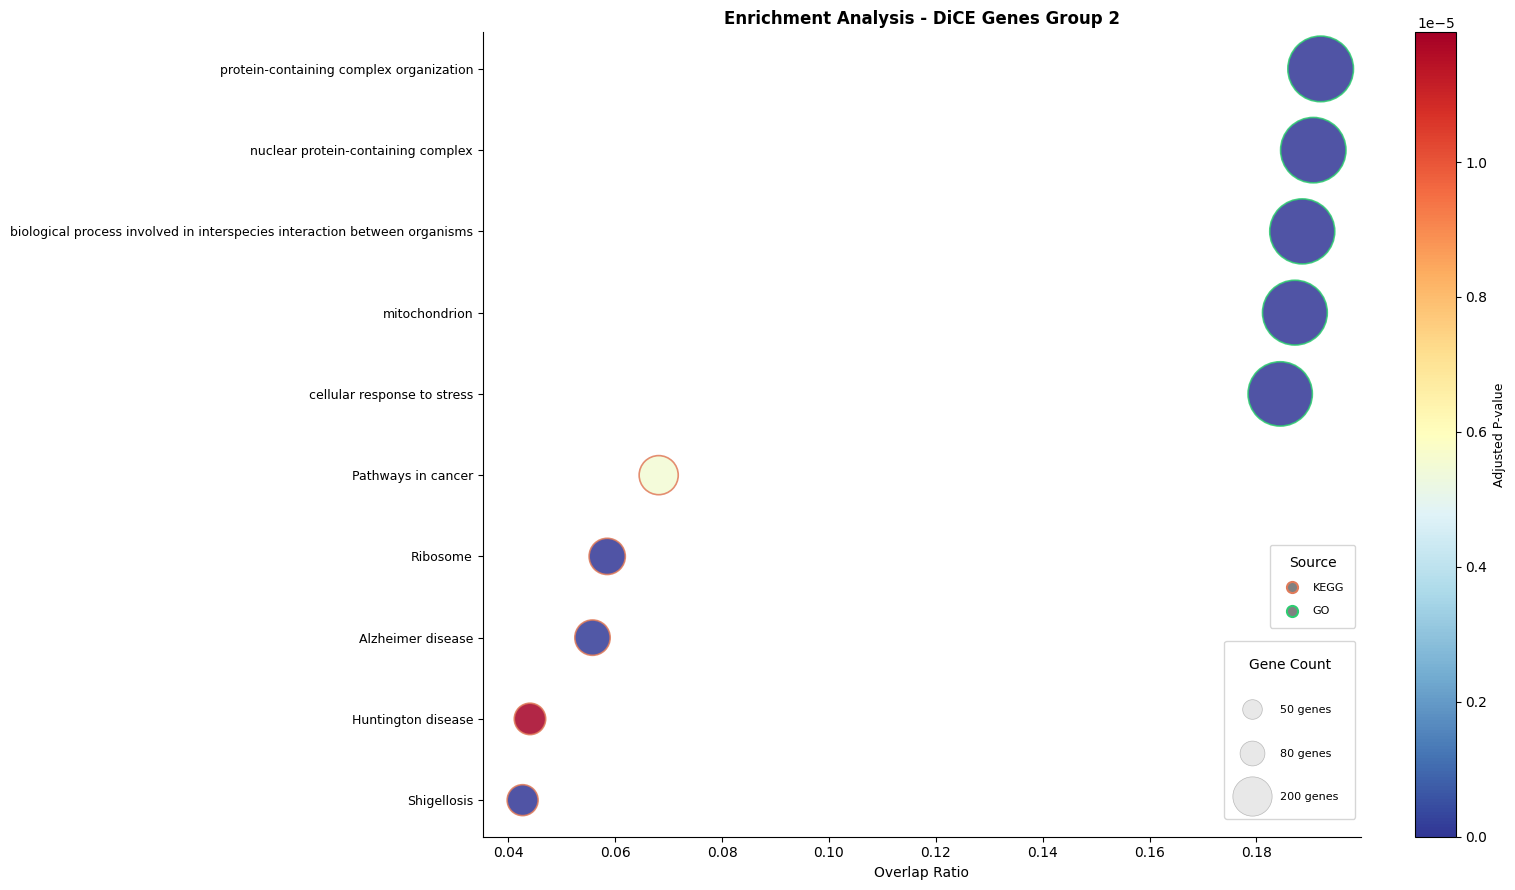

In [27]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# prep KEGG
top_kegg = results_kegg_filt.sort_values('new_overlap_rat', ascending=False).head(5).copy()
top_kegg['KEGG Pathway'] = top_kegg['KEGG Pathway'].str.replace(' - Homo sapiens (human)', '', regex=False)
top_kegg['label'] = top_kegg['KEGG Pathway']
top_kegg['source'] = 'KEGG'

# prep GO
top_go = results_go_filt.sort_values('new_overlap_rat', ascending=False).head(5).copy()
top_go['label'] = top_go['GO Term Name']
top_go['source'] = 'GO'

# join
combined = pd.concat([top_kegg, top_go], ignore_index=True)
combined = combined.sort_values('new_overlap_rat', ascending=True).reset_index(drop=True)
gene_counts = combined['Overlap'].apply(lambda x: int(x.split('/')[0]))

# color by source for clarity
source_colors = {'KEGG': '#e07b5a', 'GO': '#2ecc71'}

fig, ax = plt.subplots(figsize=(16, 9))

for source, group in combined.groupby('source'):
    idx = group.index
    gc = group['Overlap'].apply(lambda x: int(x.split('/')[0]))
    ax.scatter(
        group['new_overlap_rat'], idx,
        s=gc * 8,
        c=group['Adjusted P-value'],
        cmap='RdYlBu_r',
        edgecolors=source_colors[source],
        linewidth=1.2,
        alpha=0.85,
        vmin=combined['Adjusted P-value'].min(),
        vmax=combined['Adjusted P-value'].max(),
        label=source
    )

ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined['label'], fontsize=9)
ax.set_xlabel('Overlap Ratio', fontsize=10)
ax.set_title('Enrichment Analysis - DiCE Genes Group 2', fontsize=12, fontweight='bold')

# colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r',
     norm=plt.Normalize(combined['Adjusted P-value'].min(),
                        combined['Adjusted P-value'].max()))
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Adjusted P-value', fontsize=9)

# source legend
source_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markeredgecolor='#e07b5a', markeredgewidth=1.5,
           markersize=8, label='KEGG'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
       markeredgecolor='#2ecc71', markeredgewidth=1.5,
       markersize=8, label='GO')
]

# size legend
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',
           markeredgecolor='grey', markeredgewidth=0.5, alpha=0.5,
           markersize=np.sqrt(size*4), label=f'{size} genes')
    for size in [50, 80, 200]
]

legend2 = ax.legend(handles=size_handles, title='Gene Count',
                    bbox_to_anchor=(1, 0.25), fontsize=8,
                    frameon=True, labelspacing=3,
                    borderpad=1.5, handletextpad=1.5)

legend1 = ax.legend(handles=source_handles, title='Source',
                    bbox_to_anchor=(1, 0.37), fontsize=8,
                    frameon=True, labelspacing=1.2, borderpad=1)

ax.add_artist(legend2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('enrichment_dotplot_group2.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
combined["Adjusted P-value"]

0    2.577352e-08
1    1.192219e-05
2    1.163623e-07
3    3.120226e-37
4    5.522655e-06
5    9.535500e-23
6    1.489917e-31
7    4.384048e-27
8    2.253895e-51
9    3.114758e-27
Name: Adjusted P-value, dtype: float64

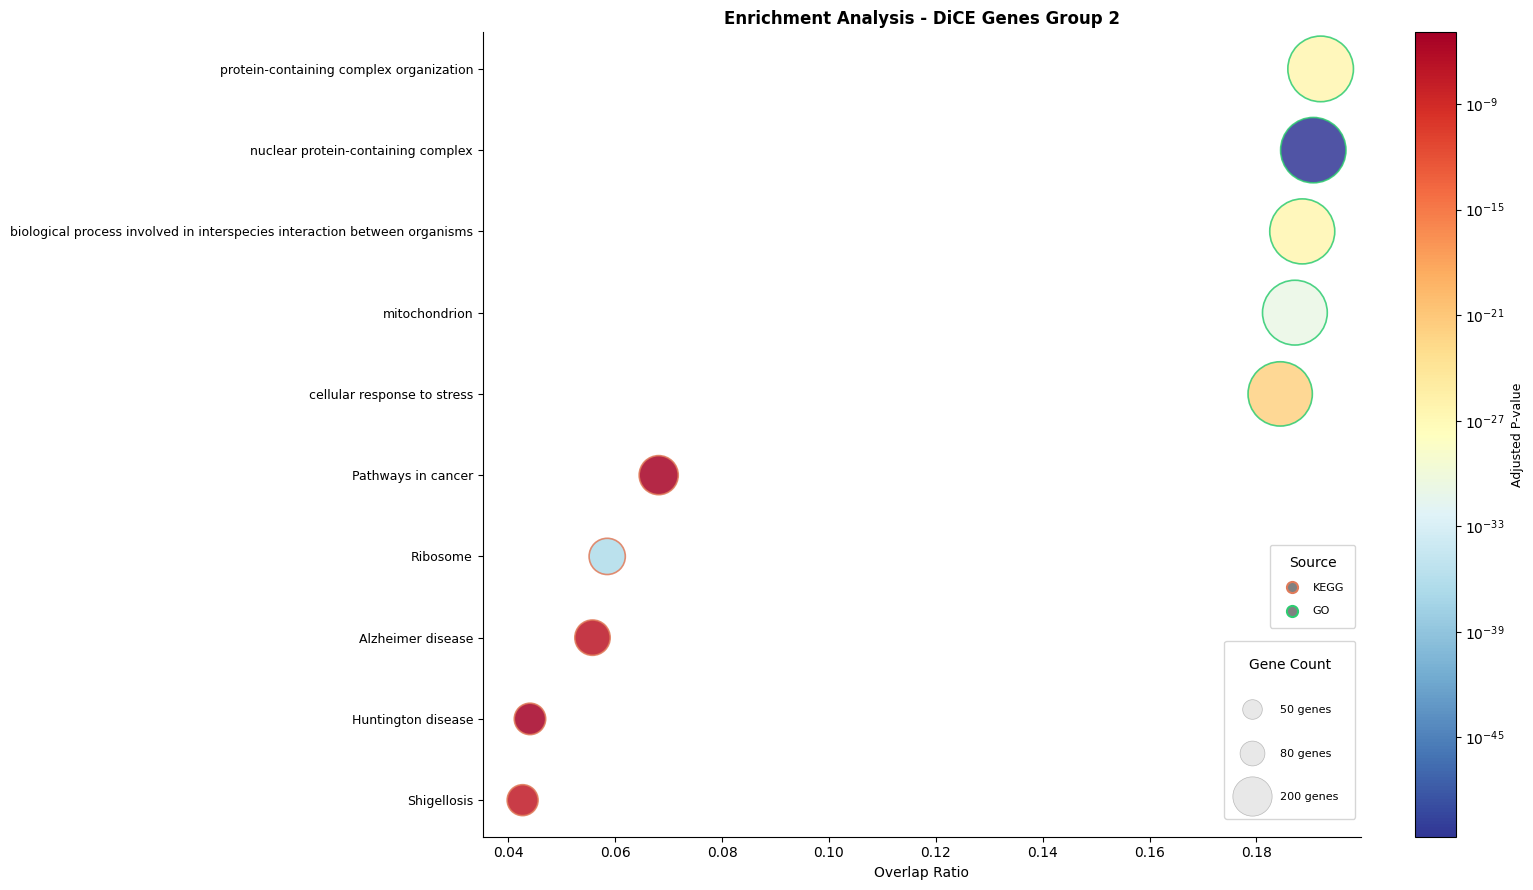

In [29]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
import numpy as np

# prep KEGG
top_kegg = results_kegg_filt.sort_values('new_overlap_rat', ascending=False).head(5).copy()
top_kegg['KEGG Pathway'] = top_kegg['KEGG Pathway'].str.replace(' - Homo sapiens (human)', '', regex=False)
top_kegg['label'] = top_kegg['KEGG Pathway']
top_kegg['source'] = 'KEGG'

# prep GO
top_go = results_go_filt.sort_values('new_overlap_rat', ascending=False).head(5).copy()
top_go['label'] = top_go['GO Term Name']
top_go['source'] = 'GO'

# join
combined = pd.concat([top_kegg, top_go], ignore_index=True)
combined = combined.sort_values('new_overlap_rat', ascending=True).reset_index(drop=True)

source_colors = {'KEGG': '#e07b5a', 'GO': '#2ecc71'}

norm = LogNorm(vmin=combined['Adjusted P-value'].min(),
               vmax=combined['Adjusted P-value'].max())

fig, ax = plt.subplots(figsize=(16, 9))

for source, group in combined.groupby('source'):
    idx = group.index
    gc = group['Overlap'].apply(lambda x: int(x.split('/')[0]))
    ax.scatter(
        group['new_overlap_rat'], idx,
        s=gc * 8,
        c=group['Adjusted P-value'],
        cmap='RdYlBu_r',
        norm=norm,
        edgecolors=source_colors[source],
        linewidth=1.2,
        alpha=0.85,
        label=source
    )

ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined['label'], fontsize=9)
ax.set_xlabel('Overlap Ratio', fontsize=10)
ax.set_title('Enrichment Analysis - DiCE Genes Group 2', fontsize=12, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Adjusted P-value', fontsize=9)

# source legend
source_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markeredgecolor='#e07b5a', markeredgewidth=1.5,
           markersize=8, label='KEGG'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markeredgecolor='#2ecc71', markeredgewidth=1.5,
           markersize=8, label='GO')
]

# size legend
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',
           markeredgecolor='grey', markeredgewidth=0.5, alpha=0.5,
           markersize=np.sqrt(size*4), label=f'{size} genes')
    for size in [50, 80, 200]
]

legend2 = ax.legend(handles=size_handles, title='Gene Count',
                    bbox_to_anchor=(1, 0.25), fontsize=8,
                    frameon=True, labelspacing=3,
                    borderpad=1.5, handletextpad=1.5)

legend1 = ax.legend(handles=source_handles, title='Source',
                    bbox_to_anchor=(1, 0.37), fontsize=8,
                    frameon=True, labelspacing=1.2, borderpad=1)

ax.add_artist(legend2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('enrichment_dotplot_group2.png', dpi=300, bbox_inches='tight')
plt.show()